In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [20]:
# Read the CSV file and store it in a DataFrame named df
df = pd.read_csv("../indata-Copy1.csv")

df.head()


,Name,Maths,Science,English
0,Amit,78,80,70
1,Riya,85,88,82
2,Smit,90,92,89
3,Neha,72,75,68
4,Raj,88,85,80


In [21]:
print("Shape of dataset:", df.shape)


print("\nColumn names in the dataset:")
print(df.columns.tolist())


Shape of dataset: (5, 4)

Column names in the dataset:
['Name', 'Maths', 'Science', 'English']


In [22]:
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Maths    5 non-null      int64 
 2   Science  5 non-null      int64 
 3   English  5 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 292.0+ bytes


In [23]:
df.describe()


,Maths,Science,English
count,5.00000,5.000000,5.000000
mean,82.60000,84.000000,77.800000
std,7.46994,6.670832,8.729261
min,72.00000,75.000000,68.000000
25%,78.00000,80.000000,70.000000
50%,85.00000,85.000000,80.000000
75%,88.00000,88.000000,82.000000
max,90.00000,92.000000,89.000000


In [24]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

Series([], dtype: int64)

In [25]:
selected_columns = [
"city",
"education_level",
"company_type",
"experience",
"training_hours",
"target"
]

df_selected = df[selected_columns].copy()

df_selected.head()

KeyError: "None of [Index(['city', 'education_level', 'company_type', 'experience',\n       'training_hours', 'target'],\n      dtype='object')] are in the [columns]"

In [ ]:
df_selected.isnull().sum()

city                  0
education_level     460
company_type       6140
experience           65
training_hours        0
target                0
dtype: int64

In [ ]:
df_clean = df_selected.dropna()

# Print shape before and after cleaning
print("Original shape:", df_selected.shape)
print("Shape after removing missing values:", df_clean.shape)


Original shape: (19158, 6)
Shape after removing missing values: (12830, 6)


In [ ]:
top_5_cities = df_clean["city"].value_counts().head(5).index.tolist()

print("Top 5 cities used for analysis:", top_5_cities)


Top 5 cities used for analysis: ['city_103', 'city_21', 'city_16', 'city_114', 'city_160']


In [ ]:
df_top_cities = df_clean[df_clean["city"].isin(top_5_cities)].copy()

# Print the shape after filtering
print("Shape after keeping top 5 cities:", df_top_cities.shape)


Shape after keeping top 5 cities: (7535, 6)


In [ ]:
sampling_fraction = 0.30

# Perform stratified sampling by city
df_sampled = df_top_cities.groupby("city", group_keys=False).apply(
    lambda x: x.sample(frac=sampling_fraction, random_state=42)
)

df_sampled = df_sampled.reset_index(drop=True)


print("Shape of sampled data:", df_sampled.shape)
df_sampled.head()


Shape of sampled data: (2261, 6)


C:\Users\sbbha\AppData\Local\Temp\ipykernel_18116\3959743971.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_top_cities.groupby("city", group_keys=False).apply(


,city,education_level,company_type,experience,training_hours,target
0,city_103,Masters,Pvt Ltd,16,29,0.0
1,city_103,Graduate,Pvt Ltd,6,46,0.0
2,city_103,Graduate,Pvt Ltd,7,28,0.0
3,city_103,Masters,Pvt Ltd,4,23,0.0
4,city_103,Graduate,Pvt Ltd,>20,121,0.0


In [ ]:
print("Stratified sampling was used so that each selected city remains represented in the sample.")
print("This helps make the sample balanced for group comparison.")


Stratified sampling was used so that each selected city remains represented in the sample.
This helps make the sample balanced for group comparison.


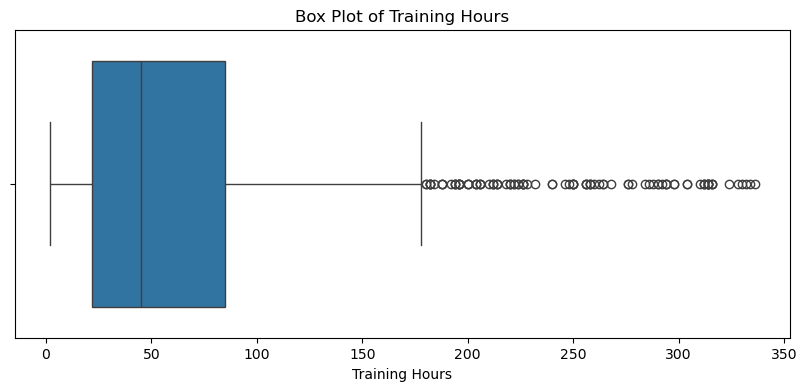

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_sampled["training_hours"])

plt.title("Box Plot of Training Hours")
plt.xlabel("Training Hours")

plt.show()

In [ ]:
z_scores = np.abs(stats.zscore(df_sampled["training_hours"]))

df_sampled["z_score"] = z_scores

df_no_outliers = df_sampled[df_sampled["z_score"] <= 3].copy()

print("Shape before removing outliers:", df_sampled.shape)
print("Shape after removing outliers :", df_no_outliers.shape)

Shape before removing outliers: (2261, 7)
Shape after removing outliers : (2208, 7)


In [ ]:
city_means = df_no_outliers.groupby("city")["training_hours"].mean()

# Print the result
print("Mean training hours by city:")
print(city_means)

Mean training hours by city:
city
city_103    56.653128
city_114    53.660959
city_16     59.393750
city_160    59.638710
city_21     56.733962
Name: training_hours, dtype: float64


In [ ]:
one_way_model = ols('training_hours ~ C(city)', data=df_no_outliers).fit()

# Create the ANOVA table
one_way_anova_table = sm.stats.anova_lm(one_way_model, typ=2)
one_way_anova_table

,sum_sq,df,F,PR(>F)
C(city),6.285619e+03,4.0,0.731177,0.570607
Residual,4.734561e+06,2203.0,NaN,NaN


In [ ]:
one_way_p_value = one_way_anova_table["PR(>F)"][0]

# Print the p-value
print("One-Way ANOVA p-value:", one_way_p_value)

# Interpret the result using significance level 0.05
if one_way_p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Conclusion: Mean training hours are significantly different across cities.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("Conclusion: Mean training hours are not significantly different across cities.")


One-Way ANOVA p-value: 0.5706069760047774
Result: Fail to reject the null hypothesis.
Conclusion: Mean training hours are not significantly different across cities.


C:\Users\sbbha\AppData\Local\Temp\ipykernel_18116\3949441141.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_way_p_value = one_way_anova_table["PR(>F)"][0]


In [ ]:
tukey_result = pairwise_tukeyhsd(
    endog=df_no_outliers["training_hours"],
    groups=df_no_outliers["city"],
    alpha=0.05
)

# Print the Tukey HSD result
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
city_103 city_114  -2.9922 0.8731 -11.5032  5.5189  False
city_103  city_16   2.7406 0.8933  -5.4836 10.9649  False
city_103 city_160   2.9856 0.9468  -8.0109 13.9821  False
city_103  city_21   0.0808    1.0  -6.8333  6.9949  False
city_114  city_16   5.7328 0.5443  -4.5098 15.9754  False
city_114 city_160   5.9778 0.6928  -6.5998 18.5553  False
city_114  city_21    3.073 0.8933  -6.1507 12.2968  False
 city_16 city_160    0.245    1.0 -12.1404 12.6303  False
 city_16  city_21  -2.6598 0.9275 -11.6196     6.3  False
city_160  city_21  -2.9047 0.9595 -14.4617  8.6522  False
---------------------------------------------------------


In [ ]:
df_two_way = df_no_outliers.dropna(subset=["education_level", "company_type"]).copy()

# Print the shape of the dataset used for Two-Way ANOVA
print("Shape used for Two-Way ANOVA:", df_two_way.shape)

# Display the first 5 rows
df_two_way.head()


Shape used for Two-Way ANOVA: (2208, 7)


,city,education_level,company_type,experience,training_hours,target,z_score
0,city_103,Masters,Pvt Ltd,16,29,0.0,0.576698
1,city_103,Graduate,Pvt Ltd,6,46,0.0,0.282157
2,city_103,Graduate,Pvt Ltd,7,28,0.0,0.594024
3,city_103,Masters,Pvt Ltd,4,23,0.0,0.680653
4,city_103,Graduate,Pvt Ltd,>20,121,0.0,1.017286


In [ ]:
two_way_formula = 'training_hours ~ C(education_level) + C(company_type) + C(education_level):C(company_type)'

# Fit the model
two_way_model = ols(two_way_formula, data=df_two_way).fit()

# Create the Two-Way ANOVA table
two_way_anova_table = sm.stats.anova_lm(two_way_model, typ=2)

# Display the table
two_way_anova_table


C:\Users\sbbha\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '
C:\Users\sbbha\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\sbbha\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 16
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(education_level),1.947059e-07,4.0,2.274474e-11,0.999996
C(company_type),6.138583e+03,5.0,5.736672e-01,0.563540
C(education_level):C(company_type),5.578795e+04,20.0,1.303384e+00,0.185470
Residual,4.671882e+06,2183.0,NaN,NaN


In [ ]:
p_education = two_way_anova_table["PR(>F)"][0]
p_company = two_way_anova_table["PR(>F)"][1]
p_interaction = two_way_anova_table["PR(>F)"][2]

# Print the p-values clearly
print("P-value for education_level effect :", p_education)
print("P-value for company_type effect    :", p_company)
print("P-value for interaction effect     :", p_interaction)


P-value for education_level effect : 0.9999961920938597
P-value for company_type effect    : 0.5635402735715622
P-value for interaction effect     : 0.1854699898177811


C:\Users\sbbha\AppData\Local\Temp\ipykernel_18116\2885638615.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_education = two_way_anova_table["PR(>F)"][0]
C:\Users\sbbha\AppData\Local\Temp\ipykernel_18116\2885638615.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_company = two_way_anova_table["PR(>F)"][1]
C:\Users\sbbha\AppData\Local\Temp\ipykernel_18116\2885638615.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_int

In [ ]:
if p_education < 0.05:
    print("education_level has a statistically significant effect on training_hours.")
else:
    print("education_level does not have a statistically significant effect on training_hours.")

# Interpret the company_type effect
if p_company < 0.05:
    print("company_type has a statistically significant effect on training_hours.")
else:
    print("company_type does not have a statistically significant effect on training_hours.")

# Interpret the interaction effect
if p_interaction < 0.05:
    print("There is a statistically significant interaction between education_level and company_type.")
else:
    print("There is no statistically significant interaction between education_level and company_type.")


education_level does not have a statistically significant effect on training_hours.
company_type does not have a statistically significant effect on training_hours.
There is no statistically significant interaction between education_level and company_type.


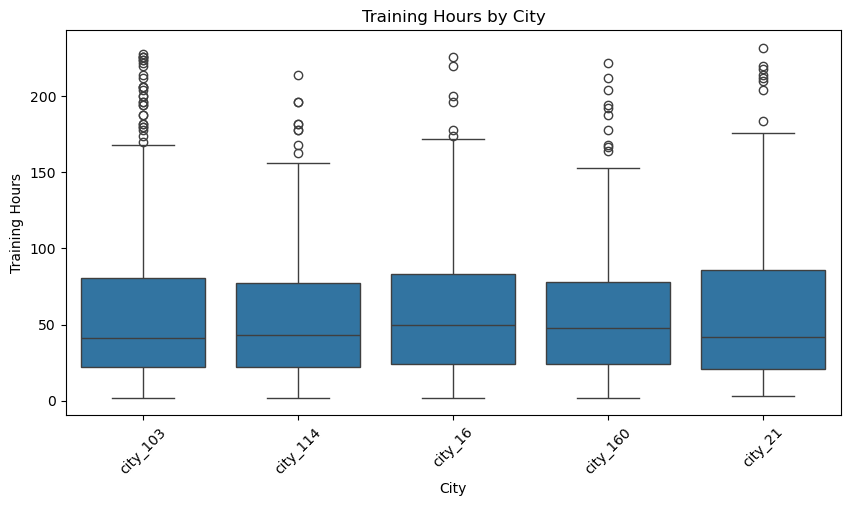

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_no_outliers["city"], y=df_no_outliers["training_hours"])
plt.title("Training Hours by City")
plt.xlabel("City")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()


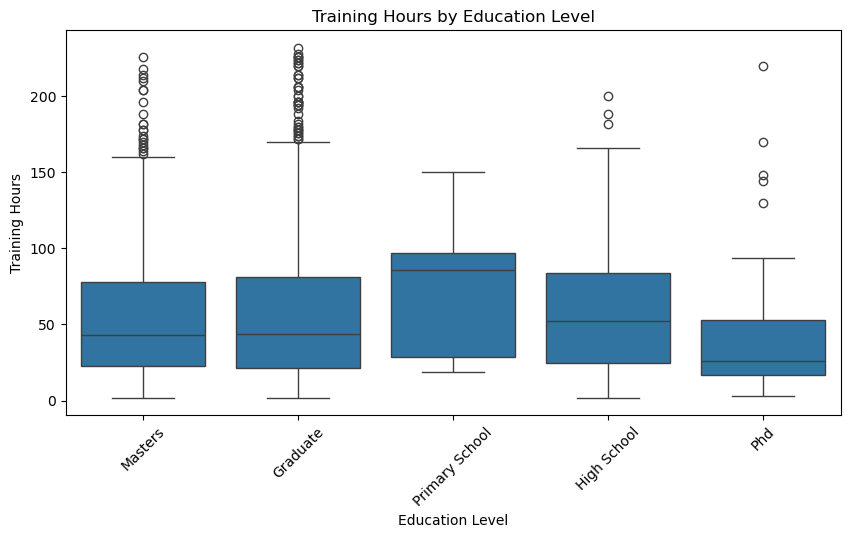

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_two_way["education_level"], y=df_two_way["training_hours"])
plt.title("Training Hours by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()

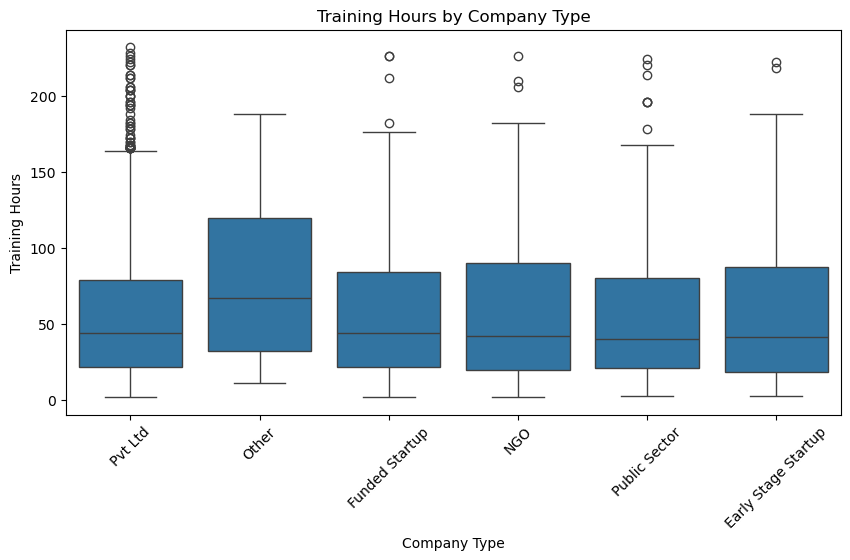

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_two_way["company_type"], y=df_two_way["training_hours"])
plt.title("Training Hours by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()


In [ ]:
print("""Notes on Sampling and Outliers
- Why stratified sampling was used: To ensure each selected city remained represented in the sample, making group comparisons more balanced.
- Whether outliers were found: Yes. Outliers were identified in training_hours using the Z-score method, and sample size reduced from 2,261 to 2,208 after removal.
""")

In [ ]:
print("""City-wise ANOVA and Tukey HSD Interpretation
- City-wise significance: No. One-way ANOVA p-value was greater than 0.05, so we fail to reject the null hypothesis.
- Tukey HSD: No city-pair comparison was significant (reject = False across pairs; adjusted p-values > 0.05).
""")

In [ ]:
print("""Two-Way ANOVA Results
- Education level effect: Not statistically significant (p-value > 0.05).
- Company type effect: Not statistically significant (p-value > 0.05).
- Interaction effect: Not statistically significant (p-value > 0.05).
""")

In [ ]:
print("""Hypothesis 1: Area vs Price
Question: Does the size (area) of a house affect its price?

H0 (Null Hypothesis): Area has no significant effect on house price.
H1 (Alternative Hypothesis): Area has a significant effect on house price.
""")

In [ ]:
print("""Hypothesis 2: Number of Bedrooms vs Price
Question: Does the number of bedrooms influence house price?

H0 (Null Hypothesis): Number of bedrooms does not affect house price.
H1 (Alternative Hypothesis): Number of bedrooms affects house price.
""")

In [ ]:
print("""Hypothesis 3: Location/Condition vs Price
Question: Does location or quality of a house impact its price?

H0 (Null Hypothesis): Location/quality has no impact on house price.
H1 (Alternative Hypothesis): Location/quality significantly impacts house price.
""")

In [ ]:
# TASK 2

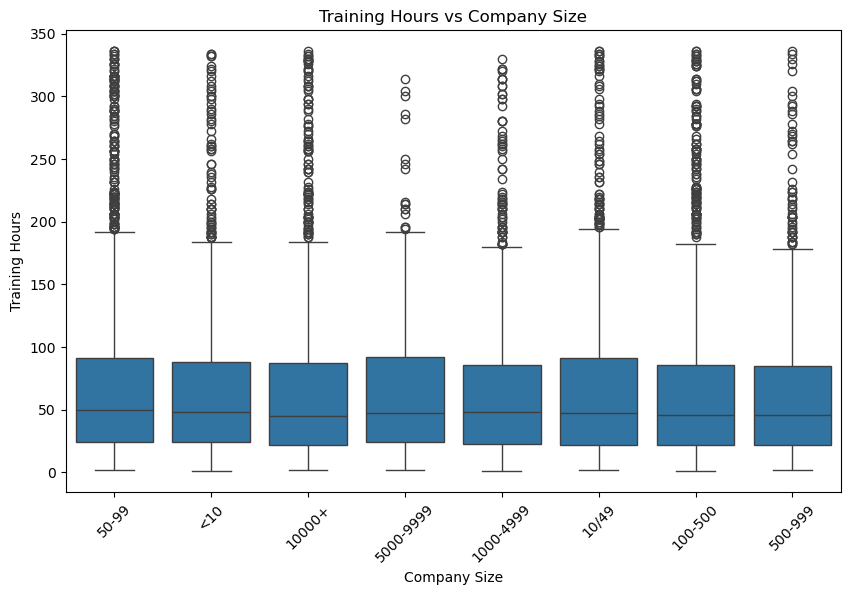

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='company_size', y='training_hours', data=df)

plt.title("Training Hours vs Company Size")
plt.xlabel("Company Size")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)

plt.show()

In [ ]:
from scipy import stats

# drop missing values (VERY IMPORTANT)
df_clean = df[['company_size', 'training_hours']].dropna()

# create groups
groups = [group['training_hours'].values 
          for name, group in df_clean.groupby('company_size')]

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 1.372404846616023
P-Value: 0.21207432548452648


In [ ]:
if p_value < 0.05:
    print("Reject H0: Training hours differ across company sizes")
else:
    print("Fail to reject H0: No significant difference")

Fail to reject H0: No significant difference


In [ ]:
print("""ANOVA Result
F-Statistic: 1.372
P-Value: 0.212

Since p-value (0.212) > 0.05, we fail to reject the null hypothesis (H0).
""")

ANOVA Result
F-Statistic: 1.372
P-Value: 0.212

Since p-value (0.212) > 0.05, we fail to reject the null hypothesis (H0).



In [ ]:
print("Do visual differences match the ANOVA result?")
print("No. The visual differences are not strong enough to indicate a statistically significant difference, which is consistent with ANOVA.")

In [ ]:
# TASK 3

In [ ]:
print("The most similar groups are city_103 and city_21, and city_16 and city_160, due to very small mean differences and high p-values.")

In [ ]:
print("The most different groups are city_114 vs city_160 and city_114 vs city_16 (largest mean differences), but the differences are still not statistically significant.")

In [ ]:
print("""Why training hours are similar across cities
- Differences in means are small relative to within-group variation.
- Group distributions overlap substantially.
- Possible reasons include standardized training programs, similar company policies, and random variation.
""")

In [ ]:
# TASK 4

In [ ]:
print("The company size category with the lowest median training hours can be interpreted as having the lowest training engagement.")

In [ ]:
print("""Improvement 1: Increase training opportunities
Provide more learning programs, workshops, and skill-development sessions, and encourage participation.

Improvement 2: Strengthen employee engagement
Conduct feedback surveys and improve work environment and career-growth support.
""")

In [ ]:
print("ANOVA indicates no statistically significant difference in training hours across company-size groups, suggesting the issue is broad rather than isolated to one group.")

In [ ]:
# TASK 5

In [ ]:
print("""Does satisfaction depend on both variables?
Yes, it can depend on both company size and experience.

However, based on the current ANOVA results (p-value > 0.05), there is no strong statistical evidence of differences by company size alone, so interaction effects may also be weak.
""")

In [ ]:
print("""What is an interaction effect?
An interaction effect occurs when the effect of one variable depends on the level of another variable.

Example in this context:
- For experienced employees, large companies may provide more training hours.
- For freshers, training hours may be similar across company sizes.
""")

In [ ]:
# TASK 6

In [ ]:
print("""What does p-value > 0.05 mean?
When p-value > 0.05, we fail to reject the null hypothesis (H0).
This means there is no statistically significant difference between group means, and observed differences may be due to random variation.
""")

In [ ]:
print("""Does this mean groups are identical?
No. It does not mean groups are identical.
It means any differences are not strong enough to be statistically significant with the current data.
""")

In [ ]:
print("""What should an analyst do next?
- Check data quality.
- Increase sample size to improve statistical power.
- Test additional variables or alternative models.
""")

What should an analyst do next?
- Check data quality.
- Increase sample size to improve statistical power.
- Test additional variables or alternative models.

